In [1]:
from moabb.paradigms import LeftRightImagery
from moabb.datasets import *

sfreq=250
paradigm = LeftRightImagery(resample=sfreq)
datasets = [
    BNCI2014004()
]


In [2]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter, ledoit_wolf_shrinkage
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler, FunctionTransformer
import warnings
from joblib import parallel_backend
from joblib import Parallel
from hoda.classification import SelectF
from sklearn.pipeline import make_pipeline
import tensorly as tl

clf = make_pipeline(
    SelectF(alpha=.05),
    FunctionTransformer(tl.to_numpy),
    StandardScaler(),
    LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
)

bttda = GreedyBTTDA(
    max_blocks=2,
    truncate=False,
    hoda_params=dict(
        rank=None,
        max_iter=128,
        tol=1e-8,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='tr',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=False,
        random_state=42,
        delta=None,
       
    ),
    verbose=True,
    extra_train_info=True,
    cv=StratifiedKFold(random_state=42, shuffle=True),
    clf=clf,
)

In [3]:
import tensorly as tl
import pandas as pd
from hoda.tensorize import stf_tensor

select_infos = []
train_infos = []
for dataset in datasets:
    for subject in dataset.subject_list:
        epochs, labels, meta = paradigm.get_data(
            dataset=dataset, 
             subjects=[subject],
             return_epochs=True
        )
        for session in meta['session'].unique():
            idc = meta['session'] == session
            epochs_ses = epochs[idc]
            labels_ses = labels[idc]
            meta_ses = meta[idc]

            X = epochs_ses.get_data()
            X = stf_tensor(X, sfreq=epochs.info['sfreq'], zscore=False )
            X = tl.tensor(X)
            y = labels_ses

            print(f'dataset={dataset.code} subject={subject} session={session}')
            bttda.fit(X,y, test=True)
            subj_select_info = pd.DataFrame(bttda.model_select_info_) 
            subj_select_info['dataset'] = dataset.code
            subj_select_info['subject'] = subject
            subj_select_info['session'] = session
            subj_train_info = pd.DataFrame(bttda.train_info_)
            subj_train_info['dataset'] = dataset.code
            subj_train_info['subject'] = subject
            subj_train_info['session'] = session
            select_infos.append(subj_select_info.reset_index())
            train_infos.append(subj_train_info.reset_index())
            # save
            select_info = pd.concat(select_infos, ignore_index=True)
            train_info = pd.concat(train_infos, ignore_index=True)
            select_info.to_csv('block_mi_select.csv')
            train_info.to_csv('block_mi_train.csv')


Sampling frequency of the instance is already 250.0, returning unmodified.
Not setting metadata
120 matching events found
No baseline correction applied
Sampling frequency of the instance is already 250.0, returning unmodified.
Not setting metadata
120 matching events found
No baseline correction applied
Sampling frequency of the instance is already 250.0, returning unmodified.
Not setting metadata
160 matching events found
No baseline correction applied
Sampling frequency of the instance is already 250.0, returning unmodified.
Not setting metadata
160 matching events found
No baseline correction applied
Sampling frequency of the instance is already 250.0, returning unmodified.
Not setting metadata
160 matching events found
No baseline correction applied
Not setting metadata
720 matching events found
No baseline correction applied


/tmp/ipykernel_1006/3487868780.py:20: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs_ses.get_data()


dataset=004-2014 subject=1 session=session_0
Model selection block 1/2...

Trying rank (1, 1, 1)	score: 0.8844
Trying rank (2, 2, 2)	score: 0.8422
Trying rank (3, 4, 4)	score: 0.8276
Trying rank (3, 8, 8)	score: 0.7782
Trying rank (3, 16, 16)	score: 0.7304
Trying rank (3, 16, 32)	score: 0.7220
Trying rank (3, 16, 64)	score: 0.7831
Trying rank (3, 16, 72)	score: 0.8113

Selected rank (1, 1, 1) with score 0.8844
New ranks: [(1, 1, 1)]


Model selection block 2/2...

Trying rank (1, 1, 1)	score: 0.7960
Trying rank (2, 2, 2)	score: 0.8093
Trying rank (3, 4, 4)	score: 0.8402
Trying rank (3, 8, 8)	score: 0.8400
Trying rank (3, 16, 16)	score: 0.7802
Trying rank (3, 16, 32)	score: 0.7778
Trying rank (3, 16, 64)	score: 0.8496
Trying rank (3, 16, 72)	score: 0.8573

Selected rank (3, 16, 72) with score 0.8573
New ranks: [(1, 1, 1), (3, 16, 72)]


Fitting block 1/2...
Fitting block 2/2...


/tmp/ipykernel_1006/3487868780.py:20: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs_ses.get_data()


dataset=004-2014 subject=1 session=session_1
Model selection block 1/2...

Trying rank (1, 1, 1)	score: 0.6651
Trying rank (2, 2, 2)	score: 0.4942
Trying rank (3, 4, 4)	score: 0.6429
Trying rank (3, 8, 8)	score: 0.5880
Trying rank (3, 16, 16)	score: 0.6364
Trying rank (3, 16, 32)	score: 0.6867
Trying rank (3, 16, 64)	score: 0.6658
Trying rank (3, 16, 72)	score: 0.6604

Selected rank (3, 16, 32) with score 0.6867
New ranks: [(3, 16, 32)]


Model selection block 2/2...

Trying rank (1, 1, 1)	score: 0.6629
Trying rank (2, 2, 2)	score: 0.6707
Trying rank (3, 4, 4)	score: 0.6758
Trying rank (3, 8, 8)	score: 0.6791
Trying rank (3, 16, 16)	score: 0.6509
Trying rank (3, 16, 32)	score: 0.6616
Trying rank (3, 16, 64)	score: 0.6642
Trying rank (3, 16, 72)	score: 0.6284

Selected rank (3, 8, 8) with score 0.6791
New ranks: [(3, 16, 32), (3, 8, 8)]


Fitting block 1/2...
Fitting block 2/2...


...

/tmp/ipykernel_1006/3487868780.py:20: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs_ses.get_data()


dataset=004-2014 subject=3 session=session_1
Model selection block 1/2...

Trying rank (1, 1, 1)	score: 0.3596
Trying rank (2, 2, 2)	score: 0.3501
Trying rank (3, 4, 4)	score: 0.3681
Trying rank (3, 8, 8)	score: 0.3974
Trying rank (3, 16, 16)	score: 0.3790
Trying rank (3, 16, 32)	score: 0.3366
Trying rank (3, 16, 64)	score: 0.4701
Trying rank (3, 16, 72)	score: 0.4398

Selected rank (3, 16, 64) with score 0.4701
New ranks: [(3, 16, 64)]


Model selection block 2/2...

Trying rank (1, 1, 1)	score: 0.4307
Trying rank (2, 2, 2)	score: 0.3865
Trying rank (3, 4, 4)	score: 0.4137
Trying rank (3, 8, 8)	score: 0.4164
Trying rank (3, 16, 16)	score: 0.4036
Trying rank (3, 16, 32)	score: 0.3580
Trying rank (3, 16, 64)	score: 0.3865
Trying rank (3, 16, 72)	score: 0.4004

Selected rank (1, 1, 1) with score 0.4307
New ranks: [(3, 16, 64), (1, 1, 1)]


Fitting block 1/2...
Fitting block 2/2...


/tmp/ipykernel_1006/3487868780.py:20: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs_ses.get_data()


dataset=004-2014 subject=3 session=session_2
Model selection block 1/2...

Trying rank (1, 1, 1)	score: 0.4473
Trying rank (2, 2, 2)	score: 0.5153
Trying rank (3, 4, 4)	score: 0.4466
Trying rank (3, 8, 8)	score: 0.4958
Trying rank (3, 16, 16)	score: 0.5155
Trying rank (3, 16, 32)	score: 0.5523
Trying rank (3, 16, 64)	score: 0.4544
Trying rank (3, 16, 72)	score: 0.4586

Selected rank (3, 16, 32) with score 0.5523
New ranks: [(3, 16, 32)]


Model selection block 2/2...

Trying rank (1, 1, 1)	


KeyboardInterrupt



In [4]:
select_info

,block,rank,fold,train_score,val_score,n_features,test_score,dataset,subject,session
0,0,"(1, 1, 1)",0,0.999307,0.700000,1,0.833333,004-2014,1,session_0
1,0,"(1, 1, 1)",1,1.000000,0.844444,1,0.868056,004-2014,1,session_0
2,0,"(1, 1, 1)",2,0.996626,0.888889,1,0.909722,004-2014,1,session_0
3,0,"(1, 1, 1)",3,0.999325,0.988889,1,0.840278,004-2014,1,session_0
4,0,"(1, 1, 1)",4,1.000000,1.000000,1,0.833333,004-2014,1,session_0
...,...,...,...,...,...,...,...,...,...,...
955,1,"(3, 16, 72)",0,1.000000,0.424242,6528,0.318519,004-2014,3,session_1
956,1,"(3, 16, 72)",1,1.000000,0.411111,6528,0.488889,004-2014,3,session_1
957,1,"(3, 16, 72)",2,1.000000,0.377778,6528,0.407407,004-2014,3,session_1
958,1,"(3, 16, 72)",3,1.000000,0.577778,6528,0.511111,004-2014,3,session_1


In [5]:
select_info

,block,rank,fold,train_score,val_score,n_features,test_score,dataset,subject,session
0,0,"(1, 1, 1)",0,0.999307,0.700000,1,0.833333,004-2014,1,session_0
1,0,"(1, 1, 1)",1,1.000000,0.844444,1,0.868056,004-2014,1,session_0
2,0,"(1, 1, 1)",2,0.996626,0.888889,1,0.909722,004-2014,1,session_0
3,0,"(1, 1, 1)",3,0.999325,0.988889,1,0.840278,004-2014,1,session_0
4,0,"(1, 1, 1)",4,1.000000,1.000000,1,0.833333,004-2014,1,session_0
...,...,...,...,...,...,...,...,...,...,...
955,1,"(3, 16, 72)",0,1.000000,0.424242,6528,0.318519,004-2014,3,session_1
956,1,"(3, 16, 72)",1,1.000000,0.411111,6528,0.488889,004-2014,3,session_1
957,1,"(3, 16, 72)",2,1.000000,0.377778,6528,0.407407,004-2014,3,session_1
958,1,"(3, 16, 72)",3,1.000000,0.577778,6528,0.511111,004-2014,3,session_1


<Axes: xlabel='block', ylabel='value'>

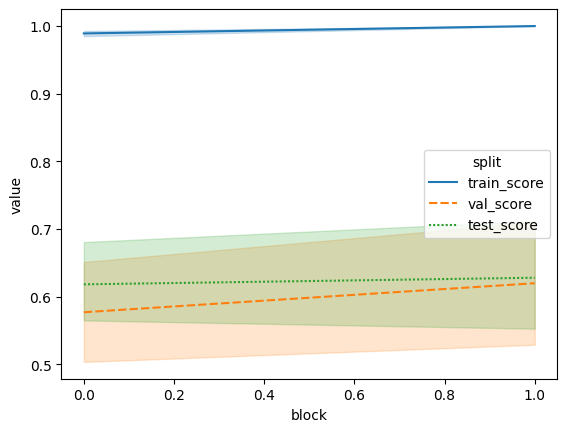

In [8]:
import seaborn as sns

idx = ['dataset', 'subject', 'session', 'block']
df = select_info.groupby(idx)[['train_score', 'val_score', 'test_score']].aggregate('mean')
df = df.melt(var_name='split', ignore_index=False)
df = df.reset_index()
sns.lineplot(data=df, x='block', y='value', hue='split', style='split')

In [9]:
train_info.to_csv('block_mi_train.csv')
train_info

,index,block,rank,F_tr,F_rt,log_loss,mse,nmse,dataset,subject,session
0,0,1,"(1, 1, 1)",0.025762,0.050664,7.544066e-02,9.850853e-01,9.850853e-01,004-2014,1,session_0
1,1,2,"(3, 16, 72)",0.000081,0.550306,2.220446e-16,6.204051e-16,6.204051e-16,004-2014,1,session_0
2,0,1,"(3, 16, 32)",0.000542,0.160359,2.016048e-10,8.127546e-01,8.127546e-01,004-2014,1,session_1
3,1,2,"(3, 8, 8)",0.000550,0.281430,1.580429e-12,7.903160e-01,7.903160e-01,004-2014,1,session_1
4,0,1,"(1, 1, 1)",0.011199,0.022117,2.169029e-01,9.896465e-01,9.896465e-01,004-2014,1,session_2
5,1,2,"(3, 8, 8)",0.001944,0.033508,3.909986e-02,9.613650e-01,9.613650e-01,004-2014,1,session_2
6,0,1,"(1, 1, 1)",0.014675,0.028982,1.580902e-01,9.906949e-01,9.906949e-01,004-2014,1,session_3
7,1,2,"(1, 1, 1)",0.011040,0.042773,1.014649e-01,9.845056e-01,9.845056e-01,004-2014,1,session_3
8,0,1,"(1, 1, 1)",0.011792,0.023288,2.026163e-01,9.940915e-01,9.940915e-01,004-2014,1,session_4
9,1,2,"(3, 4, 4)",0.003443,0.030092,1.253041e-01,9.800408e-01,9.800408e-01,004-2014,1,session_4


<Axes: xlabel='block', ylabel='nmse'>

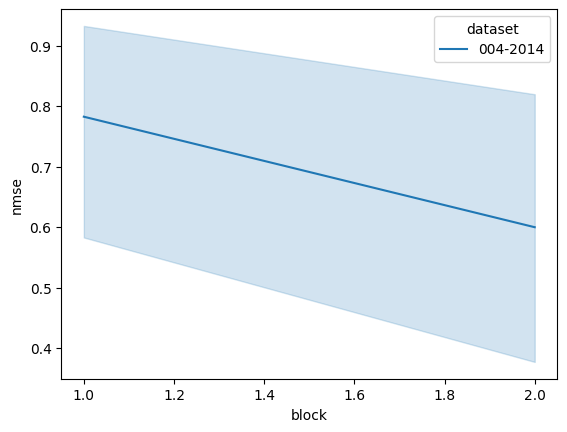

In [10]:
df = train_info.groupby(idx)
df = df['nmse'].aggregate('mean')
df = df.reset_index()
sns.lineplot(data=df, x='block',y='nmse', hue='dataset')